# RAGDoll citation-support dashboard

This notebook visualizes the citation-support judgments in `evaluation-results/aus-agent-pilot/support-bedrock-20`. Run all cells from the repository root environment.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 140)

cwd = Path.cwd().resolve()
repo = next((p for p in [cwd, *cwd.parents] if (p / 'evaluation-results').is_dir()), None)
assert repo is not None, 'Could not locate repository root from the notebook working directory'
results = repo / 'evaluation-results' / 'aus-agent-pilot' / 'support-bedrock-20_inject_vi'
judgments_path = results / 'judgments.jsonl'
assert judgments_path.exists(), f'Missing {judgments_path}'

raw = pd.read_json(judgments_path, lines=True)
metadata = pd.json_normalize(raw['metadata']).rename(columns={'topic_id': 'qid'})
details = pd.DataFrame({
    'run_id': metadata['run_id'],
    'qid': metadata['qid'],
    'sentence_index': metadata['sentence_index'],
    'citation_index': metadata['citation_index'],
    'docid': metadata['docid'],
    'support_label': raw['support_label'],
    'status': raw['status'],
    'statement': raw['statement'],
    'citation_excerpt': raw['citation'].fillna('').str.replace(r'\s+', ' ', regex=True).str.slice(0, 500),
    'error': raw['error'] if 'error' in raw else None,
})
details['support_verdict'] = details.support_label.map(
    {'FS': 'Full Support', 'PS': 'Partial Support', 'NS': 'No Support'}
).fillna('Judge Error')
counts = (details.assign(label=details.support_label.fillna('ERROR'))
          .groupby(['run_id', 'label']).size().unstack(fill_value=0)
          .reindex(columns=['FS', 'PS', 'NS', 'ERROR'], fill_value=0))
summary = counts.rename(columns={
    'FS': 'full_support', 'PS': 'partial_support',
    'NS': 'no_support', 'ERROR': 'judge_errors',
}).reset_index()
summary['total'] = summary[['full_support', 'partial_support', 'no_support', 'judge_errors']].sum(axis=1)
summary['full_support_rate'] = summary.full_support / summary.total
summary['partial_or_full_rate'] = (summary.full_support + summary.partial_support) / summary.total
print(f'Loaded {len(details):,} judgments across {details.run_id.nunique()} runs and {details.qid.nunique()} topics.')

Loaded 100 judgments across 2 runs and 4 topics.


## Overall results

In [2]:
overall = pd.Series({
    'Judgments': len(details),
    'Runs': details.run_id.nunique(),
    'Topics': details.qid.nunique(),
    'Full support': (details.support_label == 'FS').sum(),
    'Partial support': (details.support_label == 'PS').sum(),
    'No support': (details.support_label == 'NS').sum(),
    'Judge errors': details.support_label.isna().sum(),
})
display(overall.to_frame('value'))
display(summary.sort_values('total', ascending=False).reset_index(drop=True))

,value
Judgments,100
Runs,2
Topics,4
Full support,46
Partial support,41
No support,8
Judge errors,5


label,run_id,full_support,partial_support,no_support,judge_errors,total,full_support_rate,partial_or_full_rate
0,aus-agent-test-full,25,19,3,4,51,0.490196,0.862745
1,aus-agent-dev-full,21,22,5,1,49,0.428571,0.877551


## Verdict composition by run

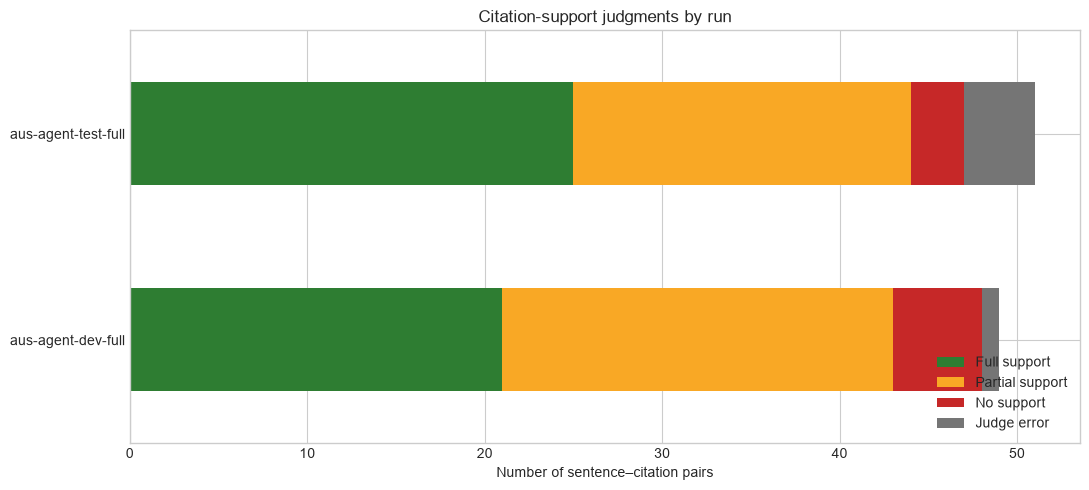

In [3]:
plot_data = summary.set_index('run_id')[['full_support', 'partial_support', 'no_support', 'judge_errors']]
plot_data = plot_data.loc[plot_data.sum(axis=1).sort_values(ascending=True).index]
ax = plot_data.plot.barh(
    stacked=True, figsize=(11, max(5, len(plot_data) * 0.45)),
    color=['#2e7d32', '#f9a825', '#c62828', '#757575']
)
ax.set(title='Citation-support judgments by run', xlabel='Number of sentence–citation pairs', ylabel='')
ax.legend(['Full support', 'Partial support', 'No support', 'Judge error'], loc='lower right')
plt.tight_layout()
plt.show()

## Support rates by run

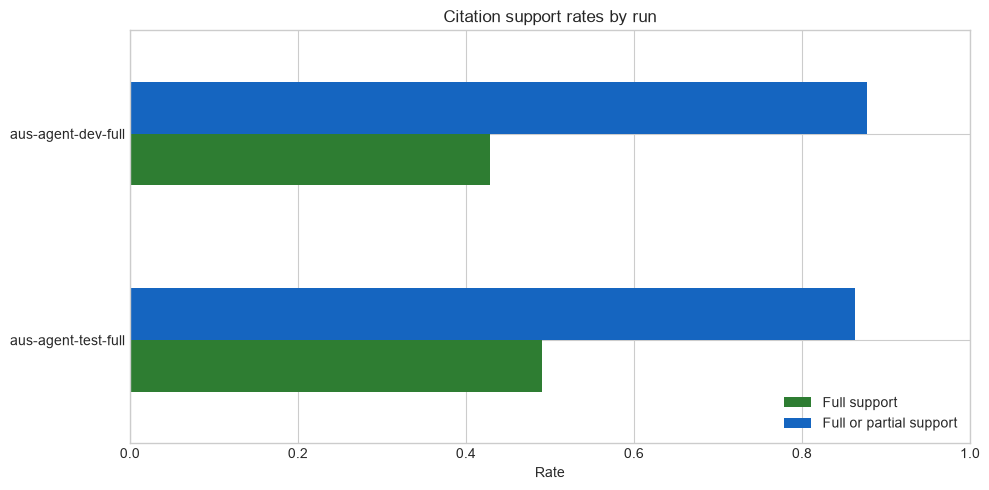

In [4]:
rates = summary.set_index('run_id')[['full_support_rate', 'partial_or_full_rate']].sort_values('partial_or_full_rate')
ax = rates.plot.barh(figsize=(10, max(5, len(rates) * 0.45)), color=['#2e7d32', '#1565c0'])
ax.set(title='Citation support rates by run', xlabel='Rate', ylabel='', xlim=(0, 1))
ax.legend(['Full support', 'Full or partial support'], loc='lower right')
plt.tight_layout()
plt.show()

## Topic-level support

,run_id,qid,mean_support,citations
1,aus-agent-dev-full,683a58c9a7e7fe4e76958488,0.652174,23
0,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,0.680000,25
3,aus-agent-test-full,rag2026-1,0.700000,20
2,aus-agent-test-full,rag2026-0,0.759259,27


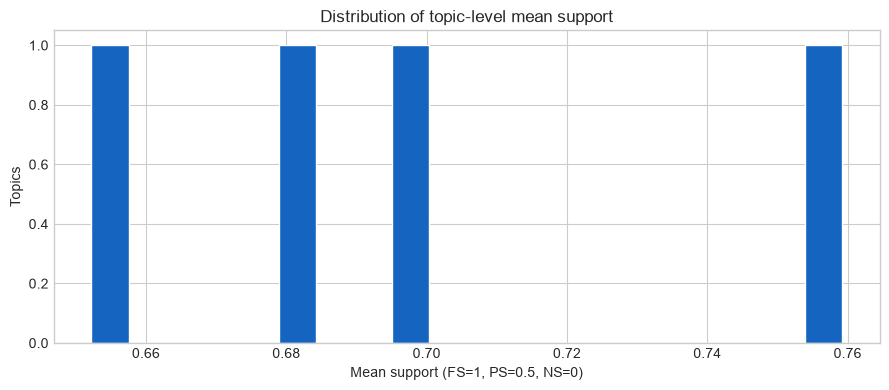

In [5]:
valid = details[details.support_label.isin(['FS', 'PS', 'NS'])].copy()
valid['support_score'] = valid.support_label.map({'FS': 1.0, 'PS': 0.5, 'NS': 0.0})
topic_scores = (valid.groupby(['run_id', 'qid'], as_index=False)
                .agg(mean_support=('support_score', 'mean'), citations=('support_score', 'size')))
display(topic_scores.sort_values(['mean_support', 'citations'], ascending=[True, False]).head(30))

ax = topic_scores.mean_support.hist(bins=20, figsize=(9, 4), color='#1565c0', edgecolor='white')
ax.set(title='Distribution of topic-level mean support', xlabel='Mean support (FS=1, PS=0.5, NS=0)', ylabel='Topics')
plt.tight_layout()
plt.show()

## Unsupported and failed judgmentsReview the claim beside its cited-passage excerpt. Use the filters to focus on a run or verdict.

In [6]:
RUN = None  # e.g. 'aus-agent-dev-full'
VERDICTS = ['No Support', 'Judge Error']

review = details[details.support_verdict.isin(VERDICTS)].copy()
if RUN:
    review = review[review.run_id == RUN]
display(review[[
    'run_id', 'qid', 'sentence_index', 'docid', 'support_verdict',
    'statement', 'citation_excerpt', 'error'
]].reset_index(drop=True))

,run_id,qid,sentence_index,docid,support_verdict,statement,citation_excerpt,error
0,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,2,shard_00218_7394,Judge Error,"Students in that class rarely see anything beyond the inscribed angle theorem, the Pythagorean theorem, and the law of cosines applied t...",Geometry Ceva's theorem tells us when three cevians emanating from the three vertices of a triangle are concurrent. This is a handy theo...,could not parse support label
1,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,19,shard_03759_81766,No Support,"These problems assume fluency with power of a point, tangent-circle relationships, and algebraic manipulation of radicals well beyond a ...","LOGIN Geometry Problems in AIME; problems and discussions. In \(\Delta ABC, AB = 3, BC = 4 \), and CA = 5. Circle \(\omega \) intersects...",NaN
2,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,20,shard_02684_29397,No Support,"Put together, these examples show that competition geometry is not simply a harder version of the same class, but a parallel curriculum ...","Sugar Land 832-999-4921 Math Competition Training, Sugar Land, Texas Star Learning offers Math Competition Training in Sugar Land, Texas...",NaN
3,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,20,shard_03597_5856,No Support,"Put together, these examples show that competition geometry is not simply a harder version of the same class, but a parallel curriculum ...","AoPS Holidays There are no classes May 30, July 4, September 5, November 21 - 26, or December 21 - January 3. Who Should Take? This cour...",NaN
4,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,22,shard_03597_5856,No Support,"AMC, AIME, and Olympiad geometry instead rewards pattern recognition, the instinct to reach for Ptolemy, Ceva, Stewart, power of a point...","AoPS Holidays There are no classes May 30, July 4, September 5, November 21 - 26, or December 21 - January 3. Who Should Take? This cour...",NaN
5,aus-agent-test-full,rag2026-0,25,shard_01653_67791,Judge Error,Treating one training session as sufficient will read as performative given both the UPenn behavior-change study and nurses' description...,"According to a new study from the University of Pennsylvania, the one-time diversity training programs that are common among organizatio...",could not parse support label
6,aus-agent-test-full,rag2026-0,29,shard_02655_60779,No Support,"Finally, leaving DEI work as unpaid, invisible labor performed mostly by nurses of color, rather than funding it and tying it to leaders...","Using Diversity and Inclusion Data to Ensure Leadership AccountabilityWhile reportedly 70% of companies say that DEI work is critical, o...",NaN
7,aus-agent-test-full,rag2026-0,26,shard_00520_38943,Judge Error,"Announcing hiring or pipeline numbers without publishing matching promotion, pay-equity, and retention data invites the ""numbers game"" c...",The Future of Nursing Must Be Diverse Inclusion has to be an intentional part of the plan as strategies to diversify the nursing field a...,could not parse support label
8,aus-agent-test-full,rag2026-1,9,shard_00460_13097,Judge Error,"On the inflammation and hormone side, clinical research out of Rice University found that people with higher grief and depression scores...","Psychologists at Rice University have reported clinical evidence of the links between grief, depression and changes to the immune and ca...",could not parse support label
9,aus-agent-test-full,rag2026-1,6,shard_00460_13097,Judge Error,Other bereavement research found that surviving spouses and parents are nearly twice as likely to die in the first three months after a ...,"Psychologists at Rice University have reported clinical evidence of the links between grief, depression and changes to the immune and ca...",could not parse support label
